# Exercises week 36

**FYS-STK3155/4155, fall 2026 — deadline Friday September 4 at midnight.**

The aim this week is that you own the two central results of Monday's lecture
— the statistics of the OLS estimator and the bias-variance decomposition,
Eq. (2.47) of the book — and the two resampling tools, the bootstrap and
$k$-fold cross-validation. The code you developed in the Tuesday session
(`week36tuesday.ipynb`) is meant to be reused here, and everything in this set
is directly reusable in Project 1.

Reading: Chapter 2, Sections 2.3–2.12 of the book; Hastie et al., Sections
7.1–7.5, 7.10 and 7.11.

## Exercise 1: Analytical exercises — the statistics of the OLS estimator

Assume the data are generated by the linear model of Eq. (2.37),
$\boldsymbol{y} = \boldsymbol{X}\boldsymbol{\theta} + \boldsymbol{\varepsilon}$,
with independent noise $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$ and a
fixed (non-stochastic) design matrix $\boldsymbol{X}$ of dimension $n \times p$.

**1a)** Show that the expectation value and variance of a single output are
(Eq. (2.39))

$$
\mathbb{E}[y_i] = \boldsymbol{X}_{i,*}\,\boldsymbol{\theta},
\qquad
\mathrm{Var}(y_i) = \sigma^2 .
$$

**1b)** Show that the OLS estimator is unbiased,
$\mathbb{E}[\hat{\boldsymbol{\theta}}] = \boldsymbol{\theta}$ (Eq. (2.40)), and
derive its variance (Eq. (2.42)),

$$
\mathrm{Var}(\hat{\boldsymbol{\theta}}) = \sigma^2\left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}.
$$

*Hint:* use
$\mathbb{E}[\boldsymbol{y}\boldsymbol{y}^T] = \boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T + \sigma^2\boldsymbol{I}_{nn}$.

**1c)** Optional: Explain how the diagonal elements of
$\sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1}$ give a confidence interval for
the coefficient $\theta_j$ (Eq. (2.43)), and why in practice $\sigma^2$ is
replaced by
$\hat{\sigma}^2 = \|\boldsymbol{y}-\boldsymbol{X}\hat{\boldsymbol{\theta}}\|_2^2/(n-p)$.
Where does the $n-p$ come from? (Think of Bessel's correction, Eq. (2.28).)

Answers:

1 a) We define that for a single output $y_i$ we have $y_i = \boldsymbol{X}_{i*} \theta + \epsilon_i$, where $\boldsymbol{X}_{i*} = x_i^T$. take expectation of this and we get:
$$
E[y_i] = E[\boldsymbol{X}_{i*} \theta + \epsilon_i] = E[\boldsymbol{X}_{i*} \theta] + E[\epsilon_i] = \boldsymbol{X}_{i*} \theta 
$$

We now want to find the variance of $y_i$. 
\begin{align*}
    V[y_i] = E[(y_i-E[y_i])^2] 
    = E[(\boldsymbol{X}_{i*} \theta + \epsilon_i - \boldsymbol{X}_{i*} \theta)^2] 
    = E[\epsilon_i^2] = \sigma^2
\end{align*}



1 b)
We now want to show that the OLS estimation is unbiased, also $E[\hat{\theta}] = \theta$. The OLS estimator is defined as $\hat{\boldsymbol{\theta}} = (\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\boldsymbol{y}$, where $y = \boldsymbol{X} \theta + \epsilon$.
\begin{align*}
    E[\hat{\boldsymbol{\theta}}] = E[(\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\boldsymbol{y}]
    =(\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^TE[\boldsymbol{y}]
    = (\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\boldsymbol{X}\boldsymbol{\theta} = \boldsymbol{\theta}
\end{align*}
This shows that the OLS estimator is unbiased. 

We also want to find the variance of the OLS estimator.
\begin{align*}
    V[\hat{\boldsymbol{\theta}}] = E[(\hat{\boldsymbol{\theta}}-E[\hat{\boldsymbol{\theta}}])^2] 
    &= E[(\hat{\boldsymbol{\theta}}-E[\hat{\boldsymbol{\theta}}])((\hat{\boldsymbol{\theta}}-E[\hat{\boldsymbol{\theta}}])^T] \\
    &= E[(\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\boldsymbol{y} - \boldsymbol{\theta})((\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\boldsymbol{y} - \boldsymbol{\theta})^T] \\
    &= E[(\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\boldsymbol{y} - \boldsymbol{\theta})(\boldsymbol{y}\boldsymbol{X}(\boldsymbol{X}^T\boldsymbol{X})^{-1} - \boldsymbol{\theta})^T] \\
    &= E[(\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\boldsymbol{y}\boldsymbol{y}\boldsymbol{X}(\boldsymbol{X}^T\boldsymbol{X})^{-1} - 2 (\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\boldsymbol{y}\boldsymbol{\theta}^T] + \boldsymbol{\theta}\boldsymbol{\theta}^T] \\
    &= (\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T E[\boldsymbol{y}\boldsymbol{y}]\boldsymbol{X}(\boldsymbol{X}^T\boldsymbol{X})^{-1} - 2 (\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T E[\boldsymbol{y}] \boldsymbol{\theta}^T] + \boldsymbol{\theta}\boldsymbol{\theta}^T \\
    &= (\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T  (\boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T + \sigma^2\boldsymbol{I})\boldsymbol{X}(\boldsymbol{X}^T\boldsymbol{X})^{-1} 
    - 2 (\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T (\boldsymbol{X}\boldsymbol{\theta}+E[\epsilon]) \boldsymbol{\theta}^T] 
    + \boldsymbol{\theta}\boldsymbol{\theta}^T \\
    &= (\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T  \boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T \boldsymbol{X}(\boldsymbol{X}^T\boldsymbol{X})^{-1} 
    + (\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T  \sigma^2\boldsymbol{I}\boldsymbol{X}(\boldsymbol{X}^T\boldsymbol{X})^{-1}
    - 2 \boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T (\boldsymbol{X}\boldsymbol{\theta} \boldsymbol{\theta}^T] 
    - 0
    + \boldsymbol{\theta}\boldsymbol{\theta}^T \\
    &= \boldsymbol{\theta}\boldsymbol{\theta}^T 
    + \sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1} 
    - 2 \boldsymbol{\theta}\boldsymbol{\theta}^T
    + \boldsymbol{\theta}\boldsymbol{\theta}^T\\
    &= \sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1}
\end{align*}
som er variansen til OLS. 

## Exercise 2: Analytical exercises — deriving the bias-variance tradeoff

Assume now, as in Section 2.10, that the true data are generated by
$\boldsymbol{y} = f(\boldsymbol{x}) + \boldsymbol{\varepsilon}$ with
$\boldsymbol{\varepsilon} \sim \mathcal{N}(0, \sigma^2)$ (Eq. (2.44)), and let
$\tilde{\boldsymbol{y}}$ be the prediction of a model fitted on a randomly
drawn training set.

**2a)** Starting from the expected squared error
$\mathbb{E}[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2]$ and adding and
subtracting $\mathbb{E}[\tilde{\boldsymbol{y}}]$, derive the decomposition of
Eq. (2.47),

$$
\mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right]
= \frac{1}{n}\sum_i\left(f_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \frac{1}{n}\sum_i\left(\tilde{y}_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \sigma^2 .
$$

Show explicitly that all three cross terms vanish, stating for each one which
assumption kills it (zero-mean noise, independence of noise and training set,
$f$ non-stochastic).

**2b)** Explain in your own words what the expectation
$\mathbb{E}[\cdot]$ runs over, and what each of the three terms means for the
polynomial-fit example of the lecture.

**2c)** In the numerical estimate (Tuesday's Case 1) the bias is computed
against $y_{\mathrm{test}}$ rather than the unknown $f$. Show that the
measured "bias" then contains $\sigma^2$, so the printed identity
`error >= bias + variance` is an inequality.

Answer:

2a)
\begin{align*}
    E[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2] 
    &= E[(\boldsymbol{y} - \tilde{\boldsymbol{y}} + E[\tilde{\boldsymbol{y}}]-E[\tilde{\boldsymbol{y}}])^2] \\
    &= E[((\boldsymbol{y} - E[\tilde{\boldsymbol{y}}]) - (\tilde{\boldsymbol{y}} -E[\tilde{\boldsymbol{y}}]))^2] \\
    &= E[(\boldsymbol{y} - E[\tilde{\boldsymbol{y}}])^2 - 2(\boldsymbol{y} - E[\tilde{\boldsymbol{y}}]) 
     (\tilde{\boldsymbol{y}} - E[\tilde{\boldsymbol{y}}])+(\tilde{\boldsymbol{y}}-E[\tilde{\boldsymbol{y}}])^2] \\
     &= E[(\boldsymbol{y} - E[\tilde{\boldsymbol{y}}])^2] - 2 E[(\boldsymbol{y} - E[\tilde{\boldsymbol{y}}]) 
     (\tilde{\boldsymbol{y}} - E[\tilde{\boldsymbol{y}}])] +E[(\tilde{\boldsymbol{y}}-E[\tilde{\boldsymbol{y}}])^2] \\
     &= E[((f(\boldsymbol{x}) + \epsilon) - E[\tilde{\boldsymbol{y}}])^2] - 2 E[((f(\boldsymbol{x}) + \epsilon) - E[\tilde{\boldsymbol{y}}]) 
     (\tilde{\boldsymbol{y}} - E[\tilde{\boldsymbol{y}}])] +E[(\tilde{\boldsymbol{y}}-E[\tilde{\boldsymbol{y}}])^2] \\
     &= E[(\epsilon + (f - E[\tilde{\boldsymbol{y}}]))^2] - 2 E[(\epsilon + (f - E[\tilde{\boldsymbol{y}}])) 
     (\tilde{\boldsymbol{y}} - E[\tilde{\boldsymbol{y}}])] +E[(\tilde{\boldsymbol{y}}-E[\tilde{\boldsymbol{y}}])^2] \\
     &= E[(\epsilon^2 + 2\epsilon(f-E[\tilde{\boldsymbol{y}}]) + (f-E[\tilde{\boldsymbol{y}}])^2] - 2 E[(\epsilon (\tilde{\boldsymbol{y}} - E[\tilde{\boldsymbol{y}}]) + (f - E[\tilde{\boldsymbol{y}}])) 
     (\tilde{\boldsymbol{y}} - E[\tilde{\boldsymbol{y}}])] +E[(\tilde{\boldsymbol{y}}-E[\tilde{\boldsymbol{y}}])^2] \\
     &= E[(\epsilon^2]+ 2 E[\epsilon(f-E[\tilde{\boldsymbol{y}}])]+ E[(f-E[\tilde{\boldsymbol{y}}])^2]- 2 (E[\epsilon (\tilde{\boldsymbol{y}} - E[\tilde{\boldsymbol{y}}])] + E[(f - E[\tilde{\boldsymbol{y}}])(\tilde{\boldsymbol{y}} - E[\tilde{\boldsymbol{y}}])])+E[(\tilde{\boldsymbol{y}}-E[\tilde{\boldsymbol{y}}])^2] \\
     &= \sigma^2+ 2 E[\epsilon(f-E[\tilde{\boldsymbol{y}}])]+ \frac{1}{n} \sum_i (f_i - E[\tilde{\boldsymbol{y}}])^2 - 2 E[\epsilon (\tilde{\boldsymbol{y}} - E[\tilde{\boldsymbol{y}}])]- 2 E[(f - E[\tilde{\boldsymbol{y}}])(\tilde{\boldsymbol{y}} - E[\tilde{\boldsymbol{y}}])]+ \frac{1}{n} \sum_i (\tilde{y}_i - E[\tilde{\boldsymbol{y}}])^2    
\end{align*}

We now need to show that the cross terms $E[\epsilon(f-E[\tilde{\boldsymbol{y}}])]$, $E[\epsilon (\tilde{\boldsymbol{y}} - E[\tilde{\boldsymbol{y}}])]$ and $E[(f - E[\tilde{\boldsymbol{y}}])(\tilde{\boldsymbol{y}} - E[\tilde{\boldsymbol{y}}])]$ wanish, also that they equal 0. 


We have that the noise $\epsilon$ is independent and normal distributed $\epsilon \sim \mathcal{N}(0,\sigma^2)$ this tels us that $E[\epsilon z] = E[\epsilon] E[z] = 0$, where z is the values in the first two equations. So that makes them wanish.

we now want to show that the last of the tree equation wanish,
$E[(f - E[\tilde{\boldsymbol{y}}])(\tilde{\boldsymbol{y}} - E[\tilde{\boldsymbol{y}}])] = (f - E[\tilde{\boldsymbol{y}}])E[(\tilde{\boldsymbol{y}} - E[\tilde{\boldsymbol{y}}])] = (f - E[\tilde{\boldsymbol{y}}])(E[\tilde{\boldsymbol{y}}] - E[E[\tilde{\boldsymbol{y}}]]) = (f - E[\tilde{\boldsymbol{y}}])(E[\tilde{\boldsymbol{y}}] -E[\tilde{\boldsymbol{y}}]) = 0$. 

that gives us the expected squared error 
\begin{align*}
 E[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2] 
 =\frac{1}{n} \sum_i (f_i - E[\tilde{\boldsymbol{y}}])^2 
 + \frac{1}{n} \sum_i (\tilde{y}_i - E[\tilde{\boldsymbol{y}}])^2
 + \sigma^2
\end{align*}

2b)

$E[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2]$ tells us the expected value of the squared difference between generated true data $y$ and the predicted $\tilde{y}$. and they are defined as the sum of the bias, and the variance and the irreducible error $\sigma^2$. The bias tels us how far the average prediction is from the truth, also it measures the systematic error. While the variance tells us how much the prediction moves when the training set is redrawn, also how sensitive my predicted value is to the sample of data. Lastly the $\sigma^2$ is the error from the noise term that we cant predict, it just is there as a minimum error. 


**2c** In this exercise we don't have a prediction for $y$ as $y = f(x) + \epsilon$, where we have defined bias as:

$$b = \left(\frac{1}{n} \sum_i f_i - E[\tilde{\boldsymbol{y}}]\right)^2$$

In our numerical estimate, we compute the bias based on $y_{\text{test}}$ instead, where it is defined as $y_{\text{test}} = f + \epsilon_{\text{test}}$ with $\epsilon_{\text{test}} \sim \mathcal{N}(0, \sigma^2)$. 

The measured bias ($Mb$) in this case is defined as:

$$\begin{aligned}
Mb &= E[(y_{\text{test}} - E[\tilde{\boldsymbol{y}}])^2] \\
&= E[(f + \epsilon_{\text{test}} - E[\tilde{\boldsymbol{y}}])^2] \\
&= E[\epsilon_{\text{test}}^2 + 2\epsilon_{\text{test}}(f - E[\tilde{\boldsymbol{y}}]) + (f - E[\tilde{\boldsymbol{y}}])^2] \\
&= E[\epsilon_{\text{test}}^2] + 2E[\epsilon_{\text{test}}(f - E[\tilde{\boldsymbol{y}}])] + E[(f - E[\tilde{\boldsymbol{y}}])^2] \\
&= \sigma^2 + 2E[\epsilon_{\text{test}}](f - E[\tilde{\boldsymbol{y}}]) + \left(\frac{1}{n} \sum_i f_i - E[\tilde{\boldsymbol{y}}]\right)^2 \\
&= b + \sigma^2 + 2E[\epsilon_{\text{test}}](f - E[\tilde{\boldsymbol{y}}])
\end{aligned}$$

So the measured bias is the true bias plus $\sigma^2$. It has an extra term:

$$2E[\epsilon_{\text{test}}(f - E[\tilde{\boldsymbol{y}}])] = 2E[\epsilon_{\text{test}}](f - E[\tilde{\boldsymbol{y}}]) = 0$$

since we have defined $E[\epsilon_{\text{test}}] = 0$. But since they have the $\text{error} \approx \text{measured bias} + \text{variance}$, this gives us the $\text{error} \geq \text{bias} + \text{variance}$.

## Exercise 3: The bias-variance tradeoff with the bootstrap

We use the same data as in the Tuesday session (and as in last week's
exercise 3),

$$
y = e^{-x^2} + 1.5\,e^{-(x-2)^2} + \varepsilon,
\qquad \varepsilon \sim \mathcal{N}(0, 0.1^2),
$$

on $x \in [-3, 3]$.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.utils import resample

np.random.seed(2026)
n = 40
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, 0.1, x.shape)

1. Split the data in training and test parts (80/20). For polynomial degrees
   $0$ to $13$, use the bootstrap (100 resamples of the training data) to
   estimate the test error, the squared bias and the variance, and plot the
   three curves as functions of the degree (compare with
   `week36_bias_variance.pdf` from the lecture — with seed 2026 you should
   reproduce it).
2. Discuss the figure in terms of Eq. (2.47): where is the model dominated by
   bias, where by variance, and where would you place the optimal degree?
3. Repeat the analysis for $n = 100$ and $n = 400$ data points and comment on
   how the curves and the optimal degree move.
4. Replace OLS by Ridge regression at a fixed high degree (say 12) and study
   the three terms as functions of $\lambda$ (for example
   `np.logspace(-6, 2, 9)`). Which term does $\lambda$ attack, and at what
   cost?

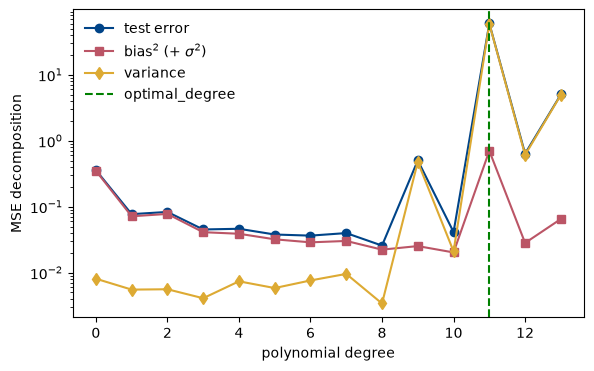

degree  0: error 0.3588  bias^2 0.3507  var 0.0081  sum 0.3588
degree  4: error 0.0463  bias^2 0.0389  var 0.0074  sum 0.0463
degree  8: error 0.0257  bias^2 0.0223  var 0.0034  sum 0.0257
degree 13: error 5.0309  bias^2 0.0651  var 4.9658  sum 5.0309

optimal degree: 11


In [28]:
# Your codenp.random.seed(2026)
#maxdegree 14 because we're using polynomial degree 0-13
#n_bootstraps 100 because we're using 100 resamples
n_bootstraps, maxdegree = 100, 14

#test_size 0.2 because we're reserving 20% of the data for testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                    random_state=2026)

error = np.zeros(maxdegree)
bias = np.zeros(maxdegree)
variance = np.zeros(maxdegree)

degrees = range(maxdegree)

#array to get the MSE
mean_scores = []

for degree in range(maxdegree):
    model = make_pipeline(PolynomialFeatures(degree=degree),
                          LinearRegression(fit_intercept=False))
    y_pred = np.empty((y_test.shape[0], n_bootstraps))
    for i in range(n_bootstraps):
        x_, y_ = resample(x_train, y_train)
        y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()

    # Expectations over training sets are averages along axis 1;
    # keepdims=True preserves the column shape and is essential
    # for the bias to come out right.
    error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
    bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
    variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))

    # negative MSE, so we will invert sign later
    scores = cross_val_score(
        model, x_train, y_train,
        scoring="neg_mean_squared_error",
        cv=10
    )
    
    mean_scores.append(scores.mean())

mean_scores = np.array(mean_scores)

# choose degree with best (highest) score
best_idx = np.argmax(mean_scores)
best_degree = degrees[best_idx]

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(range(maxdegree), error, "o-", color=BLUE, label="test error")
ax.plot(range(maxdegree), bias, "s-", color=RED, label=r"bias$^2$ (+ $\sigma^2$)")
ax.plot(range(maxdegree), variance, "d-", color=YELLOW, label="variance")
# mark the optimal degree with a vertical line
ax.axvline(x=best_degree, color="green", linestyle="--", label="optimal_degree")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE decomposition")
ax.legend(frameon=False)


plt.show()

for d in (0, 4, 8, maxdegree - 1):
    print(f"degree {d:2d}: error {error[d]:.4f}  bias^2 {bias[d]:.4f}  "
          f"var {variance[d]:.4f}  sum {bias[d] + variance[d]:.4f}") 
print(f"\noptimal degree: {best_degree}")

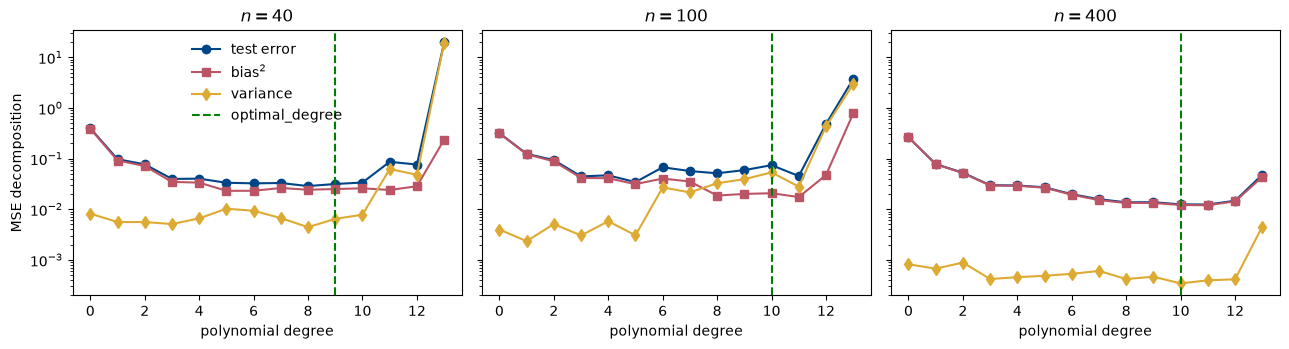

In [30]:
def bias_variance_sweep(n=40, noise=0.1, maxdegree=14, n_bootstraps=100,
                        make_model=None, seed=2026):
    mean_scores = []
    
    """Bootstrap estimate of error/bias^2/variance vs polynomial degree."""
    if make_model is None:
        make_model = lambda deg: make_pipeline(
            PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))
    np.random.seed(seed)
    x = np.linspace(-3, 3, n).reshape(-1, 1)
    y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, noise, x.shape)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                        random_state=seed)
    error, bias, variance = (np.zeros(maxdegree) for _ in range(3))
    for degree in range(maxdegree):
        model = make_model(degree)
        y_pred = np.empty((y_test.shape[0], n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()
        error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))
        # negative MSE, so we will invert sign later
        scores = cross_val_score(
            model, x_train, y_train,
            scoring="neg_mean_squared_error",
            cv=10
        )
        
        mean_scores.append(scores.mean())
    
    mean_scores = np.array(mean_scores)

    # choose degree with best (highest) score
    best_idx = np.argmax(mean_scores)
    best_degree = degrees[best_idx]
    return error, bias, variance, best_degree

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, n_ in zip(axes, (40, 100, 400)):
    err, b2, var, best_deg = bias_variance_sweep(n=n_)
    ax.plot(range(14), err, "o-", color=BLUE, label="test error")
    ax.plot(range(14), b2, "s-", color=RED, label=r"bias$^2$")
    ax.plot(range(14), var, "d-", color=YELLOW, label="variance")
    # mark the optimal degree with a vertical line
    ax.axvline(x=best_deg, color="green", linestyle="--", label="optimal_degree")
    ax.set_yscale("log")
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

As we increase n=100 nad n=400, the optimal degree increases, and even at n=400, the graph appears that the bias$^2$ line is an exact match for the variance line

In [32]:
degree_fixed = 12
lams = [0.0, 1e-4, 1e-1, 10.0]

print(f"degree {degree_fixed}, n = 40, 100 bootstraps")
print(f"{'lambda':>8}  {'error':>10}  {'bias^2':>10}  {'variance':>10}")
for lam in lams:
    if lam == 0.0:
        mk = lambda deg: make_pipeline(PolynomialFeatures(degree=deg),
                                       LinearRegression(fit_intercept=False))
    else:
        mk = lambda deg, lam=lam: make_pipeline(PolynomialFeatures(degree=deg),
                                                StandardScaler(),
                                                Ridge(alpha=lam))
    err, b2, var, optimal_degree = bias_variance_sweep(n=40, maxdegree=degree_fixed + 1,
                                       make_model=mk)
    d = degree_fixed
    label = "OLS" if lam == 0.0 else f"{lam:g}"
    print(f"{label:>8}  {err[d]:10.4f}  {b2[d]:10.4f}  {var[d]:10.4f}")

degree 12, n = 40, 100 bootstraps
  lambda       error      bias^2    variance
     OLS      0.0762      0.0284      0.0478
  0.0001      0.0338      0.0272      0.0067
     0.1      0.0289      0.0228      0.0060
      10      0.1020      0.0979      0.0041


As lambda increases, the variance decreases significantly, which increases the bias. This causes lambda to have the smallest total error at degree 12. Lambda attacks the variance at all costs.

## Exercise 4: Cross-validation

Still with the same type of data, we now select models without consuming a
test set.

1. Use scikit-learn's (or perhaps write your own) $k$-fold cross-validation function: shuffle the data,
   split into $k$ folds, use each fold as test set once, and return the mean
   and standard deviation over folds of the test MSE. Do **not** use
   `cross_val_score` inside your own function.
2. Use it with $k = 5$ to compute the CV estimate of the MSE for OLS with
   polynomial degrees $0$ to $13$, and compare with the bootstrap analysis of
   exercise 3: do the two methods point to the same degree window?
3. For a degree-6 polynomial with Ridge regression on
   $y = 3x^2 + \varepsilon$, $\varepsilon \sim \mathcal{N}(0,1)$, $n=100$
   (Tuesday's Case 2), compute the CV MSE on
   `np.logspace(-3, 5, 100)` and find the optimal $\lambda$. Any
   scaling/preprocessing must be fitted **inside** each fold — explain in one
   or two sentences why.
4. Try $k = 5, 10$ and $n$ (leave-one-out). Comment on the stability of the
   selected $\lambda$ and on the computational cost.

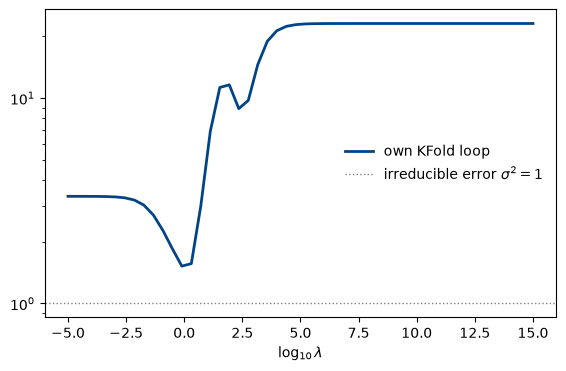

In [49]:
rng = np.random.default_rng(2026)
n = 100
x = rng.standard_normal(n)
y = 3 * x**2 + rng.standard_normal(n)     # noise variance is 1

nlambdas = 50
lambdas = np.logspace(-5, 15, nlambdas)
k = 5
kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
poly = PolynomialFeatures(degree=6)

scores_KFold = np.zeros((nlambdas, k))
for i, lmb in enumerate(lambdas):
    for j, (train_inds, test_inds) in enumerate(kfold.split(x)):
        xtrain, ytrain = x[train_inds], y[train_inds]
        xtest, ytest = x[test_inds], y[test_inds]

        Xtrain = poly.fit_transform(xtrain[:, np.newaxis])
        Xtest = poly.transform(xtest[:, np.newaxis])
        scaler = StandardScaler().fit(Xtrain)   # fitted on the training folds only

        ridge = Ridge(alpha=lmb)
        ridge.fit(scaler.transform(Xtrain), ytrain)
        ypred = ridge.predict(scaler.transform(Xtest))
        scores_KFold[i, j] = np.mean((ypred - ytest)**2)
mse_KFold = np.mean(scores_KFold, axis=1)

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(np.log10(lambdas), mse_KFold, color=BLUE, lw=2, label="own KFold loop")
ax.axhline(1.0, color="gray", lw=1, ls=":", label=r"irreducible error $\sigma^2=1$")
ax.set_yscale("log")
ax.set_xlabel(r"$\log_{10}\lambda$")
ax.legend(frameon=False)
plt.show()

best lambda 0.7906, cross-validated MSE 1.5202


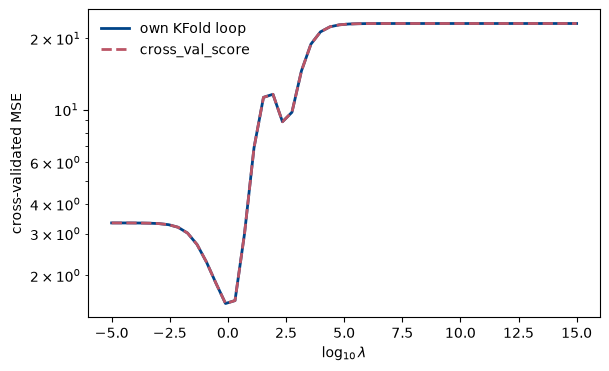

In [51]:
mse_sklearn = np.zeros(nlambdas)
for i, lmb in enumerate(lambdas):
    pipe = make_pipeline(PolynomialFeatures(degree=6), StandardScaler(),
                         Ridge(alpha=lmb))
    scores = cross_val_score(pipe, x[:, np.newaxis], y, cv=kfold,
                             scoring="neg_mean_squared_error")
    mse_sklearn[i] = np.mean(-scores)

print(f"best lambda {lambdas[best]:.4g}, cross-validated MSE {mse_sklearn[best]:.4f}")

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(np.log10(lambdas), mse_KFold, color=BLUE, lw=2, label="own KFold loop")
ax.plot(np.log10(lambdas), mse_sklearn, "--", color=RED, lw=2,
        label="cross_val_score")
ax.set_yscale("log")
ax.set_xlabel(r"$\log_{10}\lambda$")
ax.set_ylabel("cross-validated MSE")
ax.legend(frameon=False)
plt.show()

The two methods are a good fit.

best lambda 1.177, cross-validated MSE 1.4569


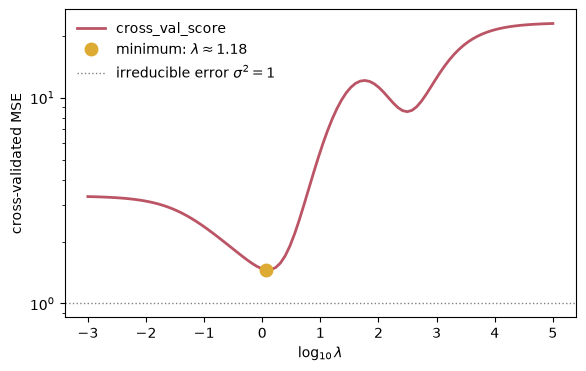

In [57]:
rng = np.random.default_rng(2026)
n = 100

nlambdas = 100
lambdas = np.logspace(-3, 5, nlambdas)
k = 5
kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
poly = PolynomialFeatures(degree=6)

mse_sklearn = np.zeros(nlambdas)
for i, lmb in enumerate(lambdas):
    pipe = make_pipeline(PolynomialFeatures(degree=6), StandardScaler(),
                         Ridge(alpha=lmb))
    scores = cross_val_score(pipe, x[:, np.newaxis], y, cv=kfold,
                             scoring="neg_mean_squared_error")
    mse_sklearn[i] = np.mean(-scores)

best = np.argmin(mse_sklearn)
print(f"best lambda {lambdas[best]:.4g}, cross-validated MSE {mse_sklearn[best]:.4f}")

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(np.log10(lambdas), mse_sklearn, color=RED, lw=2,
        label="cross_val_score")
ax.plot(np.log10(lambdas[best]), mse_sklearn[best], "o", color=YELLOW, ms=9,
        label=rf"minimum: $\lambda\approx{lambdas[best]:.3g}$")
ax.axhline(1.0, color="gray", lw=1, ls=":", label=r"irreducible error $\sigma^2=1$")
ax.set_yscale("log")
ax.set_xlabel(r"$\log_{10}\lambda$")
ax.set_ylabel("cross-validated MSE")
ax.legend(frameon=False)
plt.show()

The minimum sits near $\lambda \approx 1$ with the cross-validated MSE just above the known noise floor $\sigma^2 = 1$.

k = 5  best lambda 1.177, cross-validated MSE 1.4569
k = 10  best lambda 2.057, cross-validated MSE 1.4708
k = 100  best lambda 2.477, cross-validated MSE 1.4435


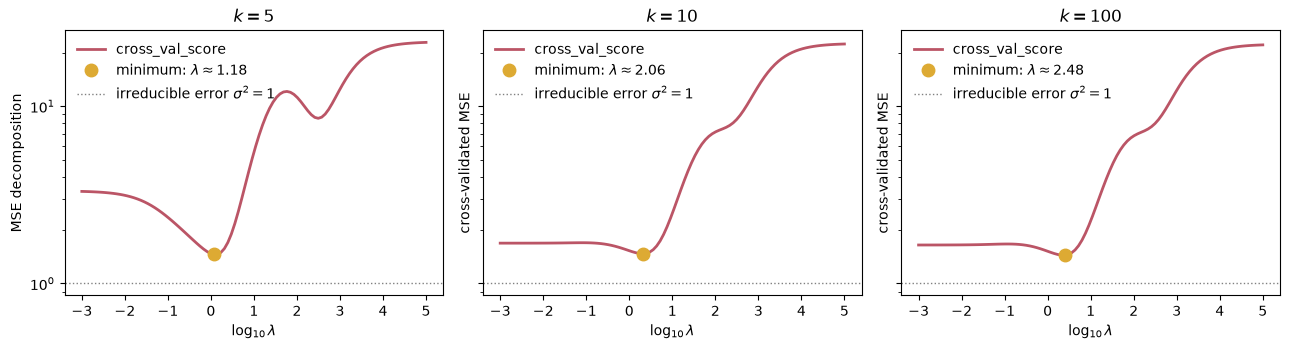

In [80]:
def cross_val_sweep(k=5):
    nlambdas = 100
    lambdas = np.logspace(-3, 5, nlambdas)
    kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
    poly = PolynomialFeatures(degree=6)

    mse_sklearn = np.zeros(nlambdas)
    for i, lmb in enumerate(lambdas):
        pipe = make_pipeline(PolynomialFeatures(degree=6), StandardScaler(),
                             Ridge(alpha=lmb))
        scores = cross_val_score(pipe, x[:, np.newaxis], y, cv=kfold,
                                 scoring="neg_mean_squared_error")
        mse_sklearn[i] = np.mean(-scores)
    
    best = np.argmin(mse_sklearn)
    return lambdas, mse_sklearn, best;


n = 100
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, k_ in zip(axes, (5, 10, n)):
    lambdas, mse_sklearn, best = cross_val_sweep(k=k_)
    print(f"\033[1mk = {k_} \033[0m best lambda {lambdas[best]:.4g}, cross-validated MSE {mse_sklearn[best]:.4f}")

    ax.plot(np.log10(lambdas), mse_sklearn, color=RED, lw=2,
            label="cross_val_score")
    ax.plot(np.log10(lambdas[best]), mse_sklearn[best], "o", color=YELLOW, ms=9,
            label=rf"minimum: $\lambda\approx{lambdas[best]:.3g}$")
    ax.axhline(1.0, color="gray", lw=1, ls=":", label=r"irreducible error $\sigma^2=1$")
    ax.set_title(f"$k = {k_}$")
    ax.set_yscale("log")
    ax.set_xlabel(r"$\log_{10}\lambda$")
    ax.set_ylabel("cross-validated MSE")
    ax.legend(frameon=False)
    
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

At At k = 10, we got a far higher minimum lambda. Then when we increase the k exponentially to k = 100, our results don't improve far greater beyond that. However, our computation cost does begin to increase. It took far longer to compute k =  100 than it took to computer k =  10. At some point, the computational cost will get too high, without significant improvement in your results to justify the cost.

## Exercise 5 (optional): error bars from the bootstrap

Use the bootstrap to attach uncertainties to fitted parameters, where the
analytical formula of exercise 1 can be checked — and where it cannot.

1. For OLS on a degree-3 polynomial fit of the exercise-3 data, bootstrap the
   training data 1000 times and histogram the resulting
   $\hat{\theta}_j^*$. Compare the bootstrap standard deviations with the
   analytical standard errors
   $\hat{\sigma}\sqrt{[(\boldsymbol{X}^T\boldsymbol{X})^{-1}]_{jj}}$ of
   Eq. (2.43).
2. Repeat for Lasso with a small penalty. Why is the bootstrap now the only
   option on the table? (Which assumption behind Eq. (2.43) fails?)

In [4]:
# Your code for exercise 5 here

### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 4 at midnight**. Collaboration is encouraged — list
your collaborators.